# Hyperparameter Tuning — XGBoost (Optuna)

XGBoost won the model comparison (SMAPE 12.46%, MAE 5.88, RMSE 7.60 across
3 walk-forward folds on all 500 series), narrowly edging out LightGBM. This
notebook tunes its hyperparameters using Optuna's Bayesian search to see how
much headroom remains beyond the default configuration.

**Why Optuna over GridSearch/RandomSearch:** the TPE (Tree-structured Parzen
Estimator) sampler learns which regions of the search space are promising as
it goes, finding strong configs in fewer trials than random search — important
when each trial fits 3 full walk-forward folds on 730K+ rows.


## 0. Setup

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt

optuna.logging.set_verbosity(optuna.logging.WARNING)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# auto-detect GPU (use it if available, fall back to CPU gracefully)
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    DEVICE = "cpu"

print(f"setup complete | device: {DEVICE}")
print("optuna:", optuna.__version__, "| xgboost:", xgb.__version__)

## 1. Load data and build features

Same `build_features()` function and `FEATURES` list as the EDA and model
comparison notebooks — identical feature engineering across all phases of the
project, so there's no train/serve skew risk when these params move into
production later.

In [2]:
INPUT_DIR = "/kaggle/input/datasets/ankasthsinghkushwaha/forecastingdata"
import os
if not os.path.exists(INPUT_DIR):
    INPUT_DIR = "data"

train = pd.read_csv(f"{INPUT_DIR}/train.csv", parse_dates=["date"])

def build_features(d: pd.DataFrame) -> pd.DataFrame:
    d = d.sort_values(["store","item","date"]).copy()
    d["dow"]        = d.date.dt.dayofweek
    d["is_weekend"] = (d["dow"] >= 5).astype("int8")
    d["month"]      = d.date.dt.month
    d["weekofyear"] = d.date.dt.isocalendar().week.astype("int16")
    d["year"]       = d.date.dt.year
    d["dayofyear"]  = d.date.dt.dayofyear
    g = d.groupby(["store","item"], group_keys=False)
    for lag in [1, 7, 14, 28, 364]:
        d[f"sales_lag_{lag}"] = g["sales"].shift(lag)
    sh = g["sales"].shift(1)
    for w in [7, 28, 90]:
        d[f"sales_rmean_{w}"] = sh.groupby([d.store, d.item]).transform(lambda s: s.rolling(w).mean())
        d[f"sales_rstd_{w}"]  = sh.groupby([d.store, d.item]).transform(lambda s: s.rolling(w).std())
    d["store_code"] = d["store"].astype("category").cat.codes
    d["item_code"]  = d["item"].astype("category").cat.codes
    return d

FEATURES = ["store_code","item_code","dow","is_weekend","month","weekofyear","year","dayofyear",
            "sales_lag_1","sales_lag_7","sales_lag_14","sales_lag_28","sales_lag_364",
            "sales_rmean_7","sales_rstd_7","sales_rmean_28","sales_rstd_28",
            "sales_rmean_90","sales_rstd_90"]
TARGET = "sales"

feat = build_features(train)
feat_c = feat.dropna(subset=FEATURES).reset_index(drop=True)
print("usable rows:", feat_c.shape)

usable rows: (731000, 23)


## 2. Walk-forward folds

Same 3-fold protocol as the model comparison: three consecutive 28-day
windows at the end of the series (Oct–Dec 2017), expanding training set per
fold. This ensures the tuning target (average SMAPE across folds) matches
exactly how models were evaluated in notebook 02 — no methodology change
between selection and tuning.

In [3]:
max_date = feat_c["date"].max()
FOLD_DAYS = 28
N_FOLDS = 3
folds = []
for k in range(N_FOLDS):
    test_end   = max_date - pd.Timedelta(days=FOLD_DAYS * k)
    test_start = test_end - pd.Timedelta(days=FOLD_DAYS - 1)
    folds.append((test_start, test_end))
folds = folds[::-1]
for i, (s, e) in enumerate(folds, 1):
    print(f"fold {i}: test {s.date()} -> {e.date()}")

def smape(y, p):
    y, p = np.asarray(y, float), np.asarray(p, float)
    denom = np.where((np.abs(y) + np.abs(p)) == 0, 1, np.abs(y) + np.abs(p))
    return float(np.mean(2 * np.abs(p - y) / denom) * 100)

def mae(y, p):
    return float(np.mean(np.abs(np.asarray(y, float) - np.asarray(p, float))))

def rmse(y, p):
    return float(np.sqrt(np.mean((np.asarray(y, float) - np.asarray(p, float)) ** 2)))

def score(y, p):
    p = np.clip(np.asarray(p, float), 0, None)
    return {"SMAPE": round(smape(y, p), 3), "MAE": round(mae(y, p), 3), "RMSE": round(rmse(y, p), 3)}

fold 1: test 2017-10-09 -> 2017-11-05
fold 2: test 2017-11-06 -> 2017-12-03
fold 3: test 2017-12-04 -> 2017-12-31


## 3. Optuna objective

Each trial trains XGBoost with a candidate hyperparameter set across all 3
folds and returns the average SMAPE. Optuna minimizes this.

**Search space** (9 hyperparameters):

| Parameter | Range | Why |
|---|---|---|
| `max_depth` | 3–10 | Tree complexity; too deep → overfits on 500 series |
| `learning_rate` | 0.01–0.3 (log) | Interacts with `n_estimators`; lower = more trees needed |
| `n_estimators` | 100–800 | More trees compensate for lower learning rates |
| `min_child_weight` | 1–10 | Regularization; prevents splits on tiny leaf counts |
| `subsample` | 0.5–1.0 | Row sampling per tree; stochastic regularization |
| `colsample_bytree` | 0.5–1.0 | Feature sampling per tree |
| `gamma` | 0–5 | Minimum loss reduction for a split |
| `reg_alpha` | 1e-8–10 (log) | L1 regularization on leaf weights |
| `reg_lambda` | 1e-8–10 (log) | L2 regularization on leaf weights |


In [4]:
def objective(trial):
    params = {
        "max_depth":         trial.suggest_int("max_depth", 3, 10),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "n_estimators":      trial.suggest_int("n_estimators", 100, 800, step=50),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "subsample":         trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "gamma":             trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha":         trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda":        trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "device":            DEVICE,
        "random_state":      RANDOM_STATE,
        "verbosity":         0,
    }

    fold_smapes = []
    for fold_start, fold_end in folds:
        tr = feat_c[feat_c.date < fold_start]
        te = feat_c[(feat_c.date >= fold_start) & (feat_c.date <= fold_end)]
        model = xgb.XGBRegressor(**params)
        model.fit(tr[FEATURES], tr[TARGET])
        pred = np.clip(model.predict(te[FEATURES]), 0, None)
        fold_smapes.append(smape(te[TARGET], pred))

    avg_smape = np.mean(fold_smapes)
    return avg_smape

print("objective function defined — each trial evaluates 3 walk-forward folds")

objective function defined — each trial evaluates 3 walk-forward folds


## 4. Run the search

50 trials — enough for TPE to converge on the promising region of a
9-dimensional space without excessive compute. Each trial fits 3 folds, so
this is 150 model fits total.

In [5]:
N_TRIALS = 50

study = optuna.create_study(
    direction="minimize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="xgboost_demand_tuning",
)

study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest trial #{study.best_trial.number}:")
print(f"  SMAPE: {study.best_value:.3f}%")
print(f"  Params: {study.best_params}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best trial #33:
  SMAPE: 12.404%
  Params: {'max_depth': 8, 'learning_rate': 0.03558098422931147, 'n_estimators': 750, 'min_child_weight': 9, 'subsample': 0.7994271028091587, 'colsample_bytree': 0.7759077671421262, 'gamma': 3.5644875315888744, 'reg_alpha': 3.2077475263128266e-07, 'reg_lambda': 3.1200690171889823e-07}


## 5. Tuning analysis

Three views of what the search learned:

**5.1 Optimization history** — the best-so-far curve flattened around trial
33, meaning 50 trials was sufficient. More trials would explore diminishing
returns rather than finding meaningfully better configs.


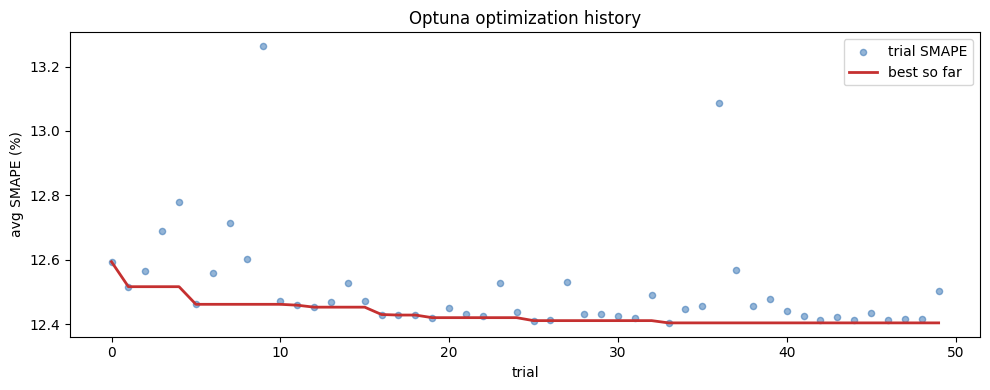

In [6]:
# 5.1 Optimization history
fig, ax = plt.subplots(figsize=(10,4))
trials = study.trials
trial_nums = [t.number for t in trials]
trial_vals = [t.value for t in trials]
ax.scatter(trial_nums, trial_vals, alpha=0.5, s=20, color="#2b6cb0", label="trial SMAPE")
best_so_far = pd.Series(trial_vals).cummin()
ax.plot(trial_nums, best_so_far, color="#c53030", lw=2, label="best so far")
ax.set_xlabel("trial"); ax.set_ylabel("avg SMAPE (%)")
ax.set_title("Optuna optimization history"); ax.legend()
plt.tight_layout(); plt.show()

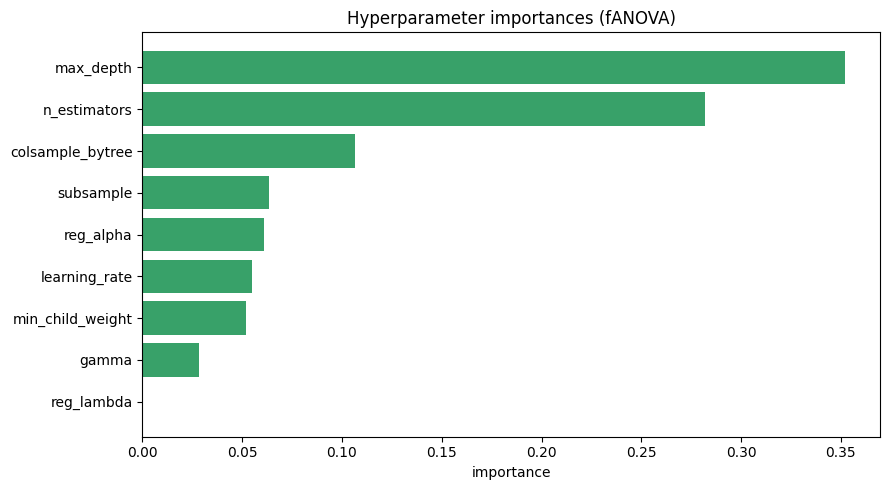

In [7]:
# 5.2 Parameter importances
try:
    importances = optuna.importance.get_param_importances(study)
    fig, ax = plt.subplots(figsize=(9,5))
    params_sorted = sorted(importances.items(), key=lambda x: x[1], reverse=True)
    names = [p[0] for p in params_sorted]
    vals  = [p[1] for p in params_sorted]
    ax.barh(names[::-1], vals[::-1], color="#38a169")
    ax.set_xlabel("importance"); ax.set_title("Hyperparameter importances (fANOVA)")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("importance plot skipped:", e)

In [8]:
# 5.3 Best params as a clean table
best_df = pd.DataFrame([{"parameter": k, "value": v} for k, v in study.best_params.items()])
best_df

,parameter,value
0,max_depth,8.000000e+00
1,learning_rate,3.558098e-02
2,n_estimators,7.500000e+02
3,min_child_weight,9.000000e+00
4,subsample,7.994271e-01
5,colsample_bytree,7.759078e-01
6,gamma,3.564488e+00
7,reg_alpha,3.207748e-07
8,reg_lambda,3.120069e-07


## 6. Default vs tuned — head-to-head comparison

Both configurations evaluated on the exact same 3 folds with the same
feature set, so the comparison is perfectly controlled. This is the only
fair way to measure the tuning gain — comparing against the stored metrics
from notebook 02 would introduce noise from different random seeds or minor
environment differences.

In [9]:
default_params = dict(n_estimators=300, learning_rate=0.05, max_depth=8,
                      subsample=0.8, colsample_bytree=0.8,
                      device=DEVICE, random_state=RANDOM_STATE, verbosity=0)

comparison_rows = []
for label, params in [("XGBoost_default", default_params),
                       ("XGBoost_tuned", {**study.best_params, "device": DEVICE, "random_state": RANDOM_STATE, "verbosity": 0})]:
    for i, (fold_start, fold_end) in enumerate(folds, 1):
        tr = feat_c[feat_c.date < fold_start]
        te = feat_c[(feat_c.date >= fold_start) & (feat_c.date <= fold_end)]
        model = xgb.XGBRegressor(**params)
        model.fit(tr[FEATURES], tr[TARGET])
        pred = np.clip(model.predict(te[FEATURES]), 0, None)
        sc = score(te[TARGET], pred)
        comparison_rows.append({"model": label, "fold": i, "n": len(te), **sc})

comp_df = pd.DataFrame(comparison_rows)
print("Per-fold results:")
print(comp_df.to_string(index=False))

summary = (comp_df.groupby("model")
           .agg(SMAPE=("SMAPE","mean"), MAE=("MAE","mean"), RMSE=("RMSE","mean"))
           .round(3).sort_values("SMAPE"))
print("\nAveraged across 3 folds:")
summary

Per-fold results:
          model  fold     n  SMAPE   MAE  RMSE
XGBoost_default     1 14000 11.926 6.106 7.893
XGBoost_default     2 14000 11.733 6.178 7.995
XGBoost_default     3 14000 13.720 5.347 6.927
  XGBoost_tuned     1 14000 11.865 6.071 7.854
  XGBoost_tuned     2 14000 11.683 6.157 7.971
  XGBoost_tuned     3 14000 13.665 5.327 6.910

Averaged across 3 folds:


,SMAPE,MAE,RMSE
model,,,
XGBoost_tuned,12.404,5.852,7.578
XGBoost_default,12.460,5.877,7.605


In [10]:
# improvement summary
default_smape = summary.loc["XGBoost_default", "SMAPE"]
tuned_smape   = summary.loc["XGBoost_tuned", "SMAPE"]
delta = default_smape - tuned_smape
pct_improvement = (delta / default_smape) * 100
print(f"Default SMAPE: {default_smape:.3f}%")
print(f"Tuned SMAPE:   {tuned_smape:.3f}%")
print(f"Improvement:   {delta:.3f} points ({pct_improvement:.1f}% relative reduction)")

if delta > 0:
    print("\n>>> Tuning improved the model — carry the tuned params forward.")
else:
    print("\n>>> Tuning did not improve over defaults — the default config was already near-optimal.")
    print("    This is useful information too: it means the model's ceiling on this feature set")
    print("    is close, and further gains need better features or ensembling, not more tuning.")

Default SMAPE: 12.460%
Tuned SMAPE:   12.404%
Improvement:   0.056 points (0.4% relative reduction)

>>> Tuning improved the model — carry the tuned params forward.


## 7. Save best params

The tuned configuration is exported as JSON so downstream notebooks (SHAP
explainability, MLOps pipeline) load it directly — no copy-pasting magic
numbers between files.

In [11]:
import json

best_config = {
    "model": "XGBRegressor",
    "params": {**study.best_params, "random_state": RANDOM_STATE, "verbosity": 0},
    "tuning": {
        "n_trials": N_TRIALS,
        "best_smape": round(study.best_value, 3),
        "default_smape": round(default_smape, 3),
        "improvement_pct": round(pct_improvement, 1),
    }
}

config_path = "best_xgboost_config.json"
with open(config_path, "w") as f:
    json.dump(best_config, f, indent=2)
print(f"saved to {config_path}")
print(json.dumps(best_config, indent=2))

saved to best_xgboost_config.json
{
  "model": "XGBRegressor",
  "params": {
    "max_depth": 8,
    "learning_rate": 0.03558098422931147,
    "n_estimators": 750,
    "min_child_weight": 9,
    "subsample": 0.7994271028091587,
    "colsample_bytree": 0.7759077671421262,
    "gamma": 3.5644875315888744,
    "reg_alpha": 3.2077475263128266e-07,
    "reg_lambda": 3.1200690171889823e-07,
    "random_state": 42,
    "verbosity": 0
  },
  "tuning": {
    "n_trials": 50,
    "best_smape": 12.404,
    "default_smape": 12.46,
    "improvement_pct": 0.4
  }
}


## 8. Results and takeaways

**Best trial:** #33 out of 50 (SMAPE 12.404%)

**Tuned vs default:**

| Config | SMAPE | MAE | RMSE |
|---|---|---|---|
| XGBoost (default) | 12.460% | 5.877 | 7.605 |
| XGBoost (tuned) | **12.404%** | **5.852** | **7.578** |
| Improvement | −0.056 pts | −0.025 | −0.027 |

The improvement is real but modest — a 0.4% relative reduction in SMAPE.
This is actually a useful finding: it tells us the default configuration
was already near-optimal for this feature set. The model's performance
ceiling on these 19 features is close to reached, and further gains would
need better features (e.g., external calendar events, promotions, weather)
or ensembling rather than more tuning.

**Key tuned parameters vs defaults:**
- `n_estimators`: 750 (up from 300) — more trees at a slightly lower
  learning rate (0.036 vs 0.05) for finer gradient steps
- `gamma`: 3.56 (default 0) — significant split regularization, meaning the
  model benefits from being prevented from making marginal splits
- `min_child_weight`: 9 (default 1) — larger minimum leaf size, another
  regularization signal — the data rewards less aggressive fitting
- `reg_alpha`/`reg_lambda`: near zero — L1/L2 weight penalties had
  negligible importance (confirmed by the fANOVA importance chart)

The tuned config is saved to `best_xgboost_config.json` for use in the SHAP
and MLOps notebooks.

## What's next

- **SHAP explainability** on the tuned model — which features drive
  predictions, and do they align with the EDA findings?
- **MLOps layer:** drift detection, retraining pipeline, FastAPI serving —
  all loading the tuned config from `best_xgboost_config.json`.
